In [1]:
import tapas.datasets
import tapas.generators
import tapas.threat_models
import tapas.attacks
import tapas.report
from utils.plotting import double_plot
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [2]:
data = tapas.datasets.TabularDataset.read("data/dummy")
target_record = data.get_records([1])
data.drop_records([1], in_place=True)
attacker_data, defender_data = data.create_subsets(n = 2, sample_size= int(len(data) / 2))
generator = tapas.generators.Raw()

data_knowledge = tapas.threat_models.AuxiliaryDataKnowledge(
      test_data= defender_data,
      aux_data= attacker_data,
      num_training_records= len(attacker_data)
)

sdg_knowledge = tapas.threat_models.BlackBoxKnowledge(
    generator,
    num_synthetic_records= len(defender_data),
)

In [3]:
print(len(defender_data.data))
target_record.data

2499


,age,color,name,gender,city
1,79.0,green,Aaron,F,Lubbock


In [ ]:
number_of_tests = 10
threat_model = tapas.threat_models.TargetedMIA(
    attacker_knowledge_data=data_knowledge,
    target_record=target_record,
    attacker_knowledge_generator=sdg_knowledge,
    generate_pairs=True,
    replace_target=True
)
attacker = tapas.attacks.GroundhogAttack()
attacker.train(threat_model, num_samples=2)
attack_summary = threat_model.test(attacker, num_samples = number_of_tests)
labels = attack_summary.labels
predictions = attack_summary.scores
print(predictions)
print(labels)
print(attack_summary.__dict__)

[0.4  0.49 0.49 0.4  0.49 0.44 0.61 0.49 0.49 0.44]
[1 0 0 1 0 1 1 0 0 1]
{'labels': array([1, 0, 0, 1, 0, 1, 1, 0, 0, 1]), 'predictions': array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0]), 'scores': array([0.4 , 0.49, 0.49, 0.4 , 0.49, 0.44, 0.61, 0.49, 0.49, 0.44]), 'generator': 'Raw', 'attack': 'Groundhog', 'dataset': 'data/dummy (AUX)', 'target_id': '1'}


In [4]:
from sklearn.ensemble import RandomForestClassifier

def MIA_attack(number_of_shadow_models, number_of_run):
   P_0 = []
   P_1 = []
   for r in range(number_of_run):
      number_of_tests = 100
      threat_model = tapas.threat_models.TargetedMIA(
         attacker_knowledge_data=data_knowledge,
         target_record=target_record,
         attacker_knowledge_generator=sdg_knowledge,
         generate_pairs=True,
         replace_target=True
      )
      attacker = tapas.attacks.GroundhogAttack(RandomForestClassifier)
      attacker.train(threat_model, num_samples=number_of_shadow_models)
      attack_summary = threat_model.test(attacker, num_samples = number_of_tests)
      labels = attack_summary.labels
      predictions = attack_summary.scores
      P_0.extend(predictions[labels == 0])
      P_1.extend(predictions[labels == 1])
   return np.mean(P_0), np.std(P_0), np.mean(P_1), np.std(P_1)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def double_plot_s(complexity: np.array, mean_0: np.array, std_0: np.array, mean_1: np.array, std_1: np.array):
    sns.set_style("whitegrid")  # Clean background with gridlines
    sns.set_palette("muted")  # Muted colors for a more refined look

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Larger plot size for clarity

    # First plot - Target not in DB
    axes[0].scatter(complexity, mean_0, color=sns.color_palette("Reds")[3], label='Mean', s=50, edgecolor='black', zorder=5)
    axes[0].fill_between(complexity, mean_0 - std_0, mean_0 + std_0, alpha=0.3, color=sns.color_palette("Reds")[2], label='Std Dev', zorder=2)
    axes[0].set_title("Target not in DB", fontsize=16, fontweight='bold', color='darkred')
    
    # Second plot - Target in DB
    axes[1].scatter(complexity, mean_1, color=sns.color_palette("Blues")[3], label='Mean', s=50, edgecolor='black', zorder=5)
    axes[1].fill_between(complexity, mean_1 - std_1, mean_1 + std_1, alpha=0.3, color=sns.color_palette("Blues")[2], label='Std Dev', zorder=2)
    axes[1].set_title("Target in DB", fontsize=16, fontweight='bold', color='darkblue')

    # Common settings for both subplots
    for ax in axes:
        ax.set_ylim(0, 1)
        ax.set_xlabel("Complexity", fontsize=14, fontweight='bold', color='gray')
        ax.set_ylabel("Probability", fontsize=14, fontweight='bold', color='gray')
        ax.legend(title='Legend', loc='upper left', fontsize=12)

        # Add gridlines with less intensity for subtle effect
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

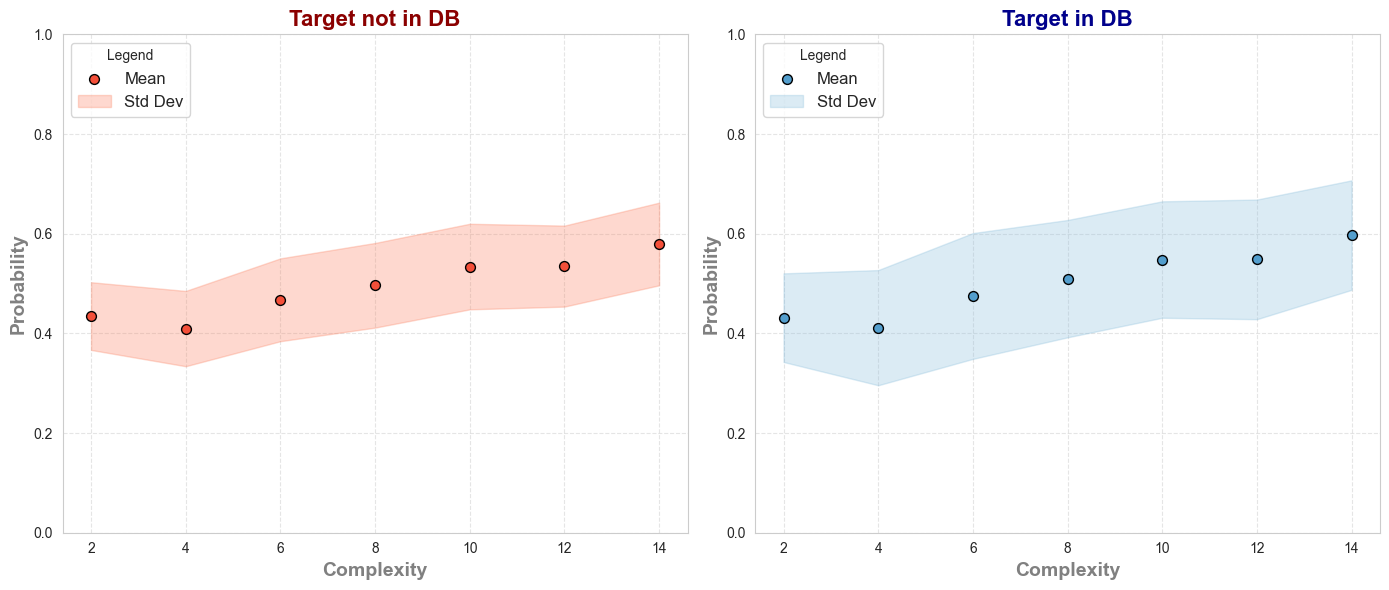

In [ ]:
R = [2,4,6,8,10,12,14]
M_0 = []
S_0 = []
M_1 = []
S_1 = []
N = 100
for i in R:
    m_0, s_0, m_1, s_1 = MIA_attack(i, N)
    M_0.append(m_0)
    S_0.append(s_0)
    M_1.append(m_1)
    S_1.append(s_1)

double_plot_s(R, np.array(M_0), np.array(S_0), np.array(M_1), np.array(S_1))